# **Solving Second-Order Equations**

The following code implements **Method 1** for solving the equation $\frac{d^2u}{dt^2} = -\,u$,$ t\in[0,1]$, subject to boundary conditions $u(0)=1$, $u(1)=\cos(1)$. In this method the loss function enforces both the boundary conditions and the equation.

I0000 00:00:1784605152.577099   10498 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784605154.114647   10498 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784605160.314215   10498 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/efra/anaconda3/envs/dl4physics/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1784605162.856115   10498 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA er

Epoch 1/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 9.9771
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.0393
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.1354
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9519
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8222 
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8560
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9713
Epoch 8/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.7630
Epoch 9/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5745 
Epoch 10/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5644
Epoch 11/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5636
Epoch 12/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5850
Epoch 13/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5486
Epoch 14/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5286
Epoch 15/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5195
Epoch 16/250
4/4 

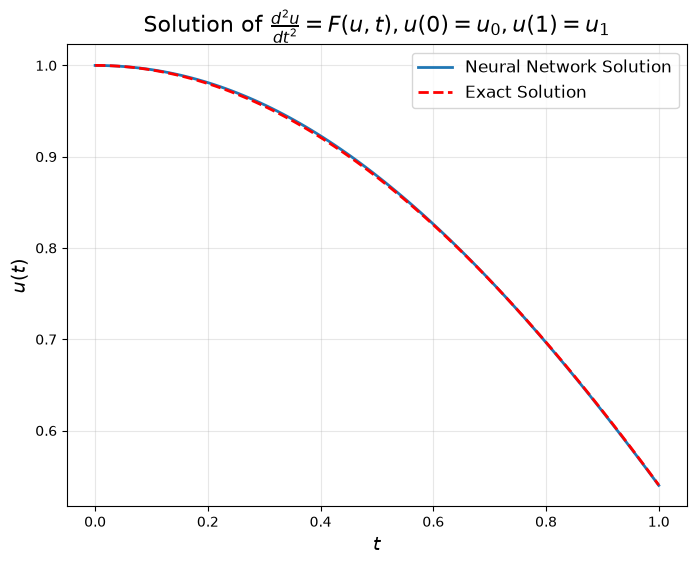

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Define the function F(u, t) (example problem)
def F(u, t):
    return -u  # Example: Simple harmonic motion (d^2u/dt^2 = -u)

# Define the exact solution for comparison (if known)
def exact_solution(t):
    return np.cos(t)  # Exact solution for F(u, t) = -u, u(0) = 1, u(1) = np.cos(1)

# Boundary conditions
u_0 = 1.0  # u(0)
u_1 = np.cos(1)  # u(1)

# Neural network to approximate u(t)
model = Sequential([
    Dense(50, activation='tanh', input_dim=1),  # Hidden layer with 50 neuronss
    Dense(1)                                   # Output layer
])

# Custom loss function
def custom_loss(y_true, y_pred):
    t_input = tf.constant(t_train, dtype=tf.float32)  # Training points

    # Compute NN(theta, t) and its derivatives
    with tf.GradientTape() as tape1:
        tape1.watch(t_input)
        with tf.GradientTape() as tape2:
            tape2.watch(t_input)
            nn_t = model(t_input)
        d_nn_dt = tape2.gradient(nn_t, t_input)  # First derivative
    d2_nn_dt2 = tape1.gradient(d_nn_dt, t_input)  # Second derivative

    # Equation loss: d^2u/dt^2 - F(u, t)
    equation_loss = tf.reduce_mean(tf.square(d2_nn_dt2 - F(nn_t, t_input)))

    # Boundary condition loss: (NN(theta, 0) - u_0)^2 + (NN(theta, 1) - u_1)^2
    boundary_loss = tf.square(model(tf.constant([[0.0]])) - u_0) + tf.square(model(tf.constant([[1.0]])) - u_1)

    # Total loss
    return equation_loss + 10*boundary_loss

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)

# Generate training data: time points in [0, 1]
t_train = np.linspace(0, 1, 100).reshape(-1, 1)
dummy_target = np.zeros_like(t_train)  # Dummy target, as the loss handles everything

# Train the model
model.fit(t_train, dummy_target, epochs=250, batch_size=32, verbose=1)

# Generate points for plotting
t_plot = np.linspace(0, 1, 100).reshape(-1, 1)
u_nn = model.predict(t_plot)  # Neural network solution
u_exact = exact_solution(t_plot)  # Exact solution

# Plot the solutions
plt.figure(figsize=(8, 6))
plt.plot(t_plot, u_nn, label="Neural Network Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linewidth=2, color='red', linestyle='dashed')
plt.title("Solution of $\\frac{d^2u}{dt^2} = F(u, t), u(0) = u_0, u(1) = u_1$", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel("$u(t)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


The next code implements **Method 2** for solving the equation $\frac{d^2u}{dt^2} = -\,u$,$ t\in[0,1]$, subject to boundary conditions $u(0)=1$, $u(1)=\cos(1)$. In this method we use the trial solution  $u(t) = (1-t) u_0 + t u_1 + t(1-t) f_{\theta}(t)$ and train the neural network $f_{\theta}(t)$.

Epoch 1/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 1.0751
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1786
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1156
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0984
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0438
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0424
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0216
Epoch 8/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0088
Epoch 9/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0142
Epoch 10/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0042 
Epoch 11/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0048
Epoch 12/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0028
Epoch 13/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0030
Epoch 14/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.7743e-04
Epoch 15/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0018
Epoch 16/250
4

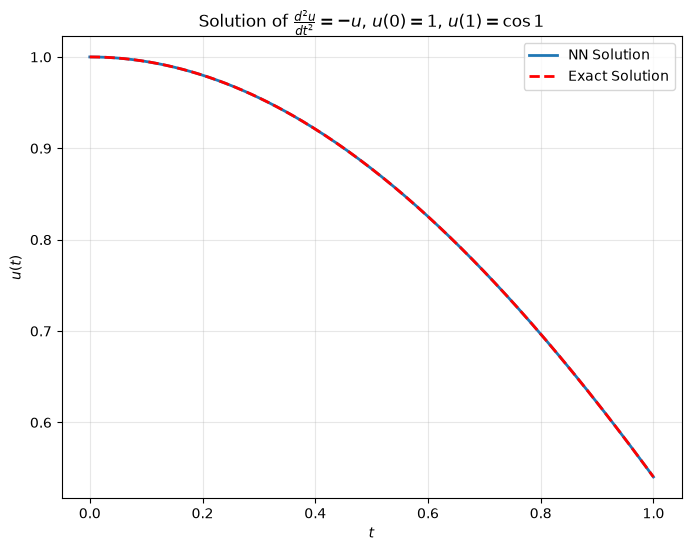

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Problem setup
def F(u, t):
    # Right‐hand side of the ODE: d^2u/dt^2 = –u
    return -u

u0 = 1.0                # u(0)
u1 = np.cos(1.0)        # u(1)

# 2. Training data (collocation points in [0,1])
t_train = np.linspace(0, 1, 100, dtype=np.float32)[:, None]
dummy_y = np.zeros_like(t_train)

# 3. Build the network that models the correction term NN(θ,t)
model = Sequential([
    Input(shape=(1,)),
    Dense(50, activation='tanh'),
    Dense(50, activation='tanh'),
    Dense(1)
])

# 4. Custom loss enforcing the differential equation and built‐in BCs
def custom_loss(y_true, y_pred):
    t = tf.constant(t_train)                   # shape (100,1)
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        nn = model(t)                          # NN(θ,t)
        # Trial solution: u(t) = (1–t)u0 + t u1 + t(1–t)*NN(θ,t)
        u = (1 - t)*u0 + t*u1 + t*(1 - t)*nn
        du_dt  = tape.gradient(u, t)           # 1st derivative
        d2u_dt2 = tape.gradient(du_dt, t)      # 2nd derivative
    # residual of the ODE
    eq_loss = tf.reduce_mean((d2u_dt2 - F(u, t))**2)
    return eq_loss

# 5. Compile & train
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)
model.fit(t_train, dummy_y, epochs=250, batch_size=32, verbose=1)

# 6. Evaluate & plot
t_plot = np.linspace(0, 1, 200, dtype=np.float32)[:, None]
nn_pred = model.predict(t_plot)
u_nn = (1 - t_plot)*u0 + t_plot*u1 + t_plot*(1 - t_plot)*nn_pred
u_exact = np.cos(t_plot)

plt.figure(figsize=(8,6))
plt.plot(t_plot, u_nn,    label="NN Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linestyle='--', color='red', linewidth=2)
plt.title(r"Solution of $\frac{d^2u}{dt^2}=-u$, $u(0)=1$, $u(1)=\cos1$")
plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


The following code considers the aforementioned boundary problem with boundary conditions $u(0)=1$ and $u(15) = \cos 15$. We notice that the neural network struggles to learn the exact solution.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


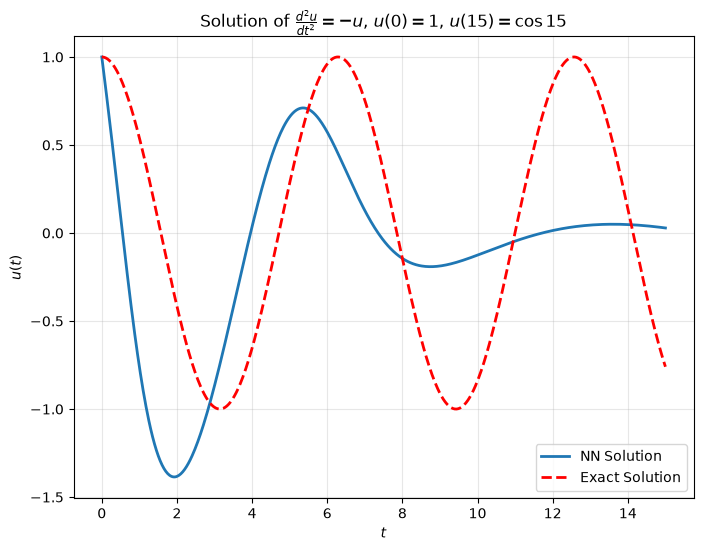

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Problem setup
def F(u, t):
    # Right‐hand side of the ODE: d^2u/dt^2 = –u
    return -u

u0 = 1.0                # u(0)
u1 = np.cos(15.0)        # u(1)

# 2. Training data (collocation points in [0,3])
t_train = np.linspace(0, 15, 600, dtype=np.float32)[:, None]
dummy_y = np.zeros_like(t_train)

# 3. Build the network that models the correction term NN(θ,t)
model = Sequential([
    Input(shape=(1,)),
    Dense(50, activation='tanh'),
    Dense(50, activation='tanh'),
    Dense(50, activation='tanh'),
    Dense(1)
])

# 4. Custom loss enforcing the differential equation and built‐in BCs
def custom_loss(y_true, y_pred):
    t = tf.constant(t_train)
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        nn = model(t)                          # NN(θ,t)
        # Trial solution: u(t) = (1–t)u0 + t u1 + t(1–t)*NN(θ,t)
        u = (1 - t)*u0 + t*u1 + t*(1 - t)*nn
        du_dt  = tape.gradient(u, t)           # 1st derivative
        d2u_dt2 = tape.gradient(du_dt, t)      # 2nd derivative
    # residual of the ODE
    eq_loss = tf.reduce_mean((d2u_dt2 - F(u, t))**2)
    return eq_loss

# 5. Compile & train
model.compile(optimizer=Adam(learning_rate=0.01), loss=custom_loss)
model.fit(t_train, dummy_y, epochs=250, batch_size=32, verbose=0)

# 6. Evaluate & plot
t_plot = np.linspace(0, 15, 600, dtype=np.float32)[:, None]
nn_pred = model.predict(t_plot)
u_nn = (1 - t_plot)*u0 + t_plot*u1 + t_plot*(1 - t_plot)*nn_pred
u_exact = np.cos(t_plot)

plt.figure(figsize=(8,6))
plt.plot(t_plot, u_nn,    label="NN Solution", linewidth=2)
plt.plot(t_plot, u_exact, label="Exact Solution", linestyle='--', color='red', linewidth=2)
plt.title(r"Solution of $\frac{d^2u}{dt^2}=-u$, $u(0)=1$, $u(15)=\cos15$")
plt.xlabel("$t$")
plt.ylabel("$u(t)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
